## Used libraries

In [2]:
import pandas as pd

## Transmittance Model

This is the theorical Transmittance model proposed by Alonso et al. 

In [3]:
# Archivo para obtener los valores de transmitancia del vidrio

#print(t_v[:,0][0])
def modelo_transmitancia(d, gamma):
    """
    x = longitud de onda
    d = espesor de la película
    t_vidrio = transmitancia del vidrio, valor experimental
    rugo_1 = rugosidad_1
    rugo_2 = rugosidad_2
    sellmeier = es el arreglo donde van a estar los coeficientes de la ecuacion de Sellmeier
    absorcion =  es el arreglo donde se van a guardar los coeficientes de la ecuacion de la absorcion
    ne = concentracion de electrones

    """
    x = np.arange(190, 1101, 1) # Set the x array
    rugo_1, rugo_2, A, B, C, D, E, alpha, beta, ne = 12, 16, 2.0065, 1.574e6, 1e7, 1.5868, 260.63, 5.0e-3, 1.0e1, 2.1e26 

    
    # Constantes utilizadas

    c = 3e8 # Velocidad de la luz

    mu = 3.90e-4 # Movilidad

    df = pd.read_csv('../../experimental_samples/Background_data/TexpglassO.txt', sep = "\t", header = 0)
    t_v = df.values

    sellmeier = [A, B, C, D, E]

    absorcion = [alpha, beta, gamma]

    #ome_pla = np.sqrt(3182.61/0.417)*ne #Frecuencia de Plasma

    # Funciones

    def frecuencia(x):

        omega = 2 * np.pi * c * 1e9 / x

        return omega

    def gamma_f(x):

        gama = 2.8e11*x

        return gama

    def e1f_f(omega,gama,ne):

        return -(3182.61*ne)/(omega**2 + gama**2)

    def e2f_f(omega,gama,ne):

        return (3182.61 * ne * gama)/(omega * (omega**2 + gama**2))

    def e1b_f(x,sellmeier):
        # A = 2.0065
        # B = 1.574e6
        # C = 1e7
        # D = 1.5868
        # E = 260.63
        return sellmeier[0] + (sellmeier[1] * x**2)/(x**2 - sellmeier[2]**2 + 1e-6) + (sellmeier[3] * x**2)/(x**2 - sellmeier[4]**2 + 1e-6)

    def e2b_f(x):

        return 0.0

    def e1_f(e1f,e1b):

        return e1f + e1b

    def e2_f(e2f,e2b):

        return e2f + e2b

    def ng_f(t_v):
        """
        t_v transmitancia del vidrio
        """
        return (1/t_v) + np.sqrt(1/(t_v**2) - 1)

    def n_f(e1,e2):

        return (1/np.sqrt(2)) * np.sqrt(e1 + np.sqrt(e1**2 + e2**2)) + 1e-6

    def kapa_f(e1,e2):

        return (1/np.sqrt(2)) * np.sqrt(-e1 + np.sqrt(e1**2 + e2**2))

    def neff1_f(n):

        return np.sqrt((1/2) * (n**2 + 1))

    def T1_f(neff1,x,n,rugo_1):

        return np.exp(-0.5 * (2 * np.pi * rugo_1 * (neff1 - 1))**2 / x**2) * (n/1) * (4/(n + 1)**2)

    def T2_f(neff1,x,ng,n,rugo_2):

        return np.exp(-0.5 * (1/x**2) * (2 * np.pi * rugo_2 * (neff1 - 1))**2) * (ng/n) * 4 * (n**2) * (1/(n + ng)**2)

    def T3_f(ng):

        return (1/ng) * 4 * ng**2 * (1/(1 + ng)**2)

    def R1_f(n,x,rugo_1):

        return np.exp(-2 * (2 * np.pi * rugo_1 * n)**2 * (1/x)**2) * (n - 1)**2 * (1/(n + 1))**2

    def R2_f(n,x,ng,rugo_2):

        return np.exp(-2 * (2 * np.pi * rugo_2 * n)**2 * (1/x)**2) * (n - ng)**2 * (1/(n + ng))**2

    def R21_f(n,ng):

        return (n - ng)**2 * (1/(n + ng)**2)

    def R3_f(ng):

        return (ng - 1)**2 * (1/(ng + 1)**2)

    def phi_f(n,d,x):

        return 4 * np.pi * n * d * (1/x)

    def alfa_f(kapa,x,absorcion):
        #alpha_0 = 2.5e-3
        #beta = 9.8
        #lambdag = 363

        return kapa * 4 * np.pi * (1/x) + absorcion[0] * np.exp(1240 * absorcion[1] * ((1/x) - (1/absorcion[2])))

    def Tf_f(T1,T2,alfa,d,phi,R1,R2):

        exp1 = np.exp(np.clip(-alfa * d, -700, 700))
        exp2 = np.exp(np.clip(-2 * alfa * d, -700, 700))
        
        denominator = 1 - 2 * np.sqrt(R1 * R2) * np.cos(phi) * exp1 + R1 * R2 * exp2
        result = (T1 * T2) * exp1 / denominator

        return result
        #(T1 * T2) * np.exp(-alfa * d) / (1 - 2 * np.sqrt(R1 * R2) * np.cos(phi) * np.exp(-alfa * d) + R1 * R2 * np.exp(-2 * alfa * d))

    def T_f(T3,R21,R3,Tf):

        return 1.0 * ((T3 / (1 - R21 * R3)) * Tf * 100)

    def N_f(T1,R1):

        return T1 + k

    # Realizamos los calculos en cadena para obtener la transmitancia del modelo.

    omega = frecuencia(x) # Check 

    gama = gamma_f(x) # Check 

    e1f = e1f_f(omega,gama,ne)

    e2f = e2f_f(omega,gama,ne)

    e1b = e1b_f(x,sellmeier)

    e2b = e2b_f(x)

    e1 = e1_f(e1f,e1b)

    e2 = e2_f(e2f,e2b)

    ng = ng_f(t_v[:,1]) # Al ser un df, se transforma en un arreglo donde tomo solo la segunda columna

    #nswanep = nswanep(e1b[0])

    n = n_f(e1,e2)

    kapa = kapa_f(e1,e2)

    neff1 = neff1_f(n)

    T1 = T1_f(neff1,x,n,rugo_1)

    T2 = T2_f(neff1,x,ng,n,rugo_2)

    T3 = T3_f(ng)

    R1 = R1_f(n,x,rugo_1)

    R2 = R2_f(n,x,ng,rugo_2)

    R21 = R21_f(n,ng)

    R3 = R3_f(ng)

    phi = phi_f(n,d,x)

    alfa = alfa_f(kapa,x,absorcion)

    Tf = Tf_f(T1,T2,alfa,d,phi,R1,R2)

    T = T_f(T3,R21,R3,Tf)

    # Input   x, t_vidrio, d, rugo_1, rugo_2, sellmeier, absorcion, ne / x longitud de onda 
    # Output  T, d, rugo_1, rugo_2, sellmeier, absorcion, ne / T transmitancia 
    if np.isnan(T).any():
        print('NAN: T')
    
    return np.nan_to_num(T, nan=1e-6) #, d, rugo_1, rugo_2, sellmeier, absorcion, ne

## Experimental Samples

In [4]:
data = pd.read_pickle('../../results/dataframe_spectrum_thickness_145_final.pkl')
data.head()

,Nombre,Nombre-Arc,Espesor,Error,Error Porcentual,Espectro
0,ANZO32,ANZO32M,91.223787,12.300000,10.000000,"[[[0.071], [0.058], [0.055999], [0.08], [0.055..."
1,ANZO01-1,ANZO011M,141.565084,18.100000,10.925087,"[[[0.037], [0.078], [0.045], [0.092], [0.049],..."
2,ANZO30,ANZO30M,167.256504,21.600000,10.256410,"[[[0.006999], [0.102], [0.029], [0.08], [0.035..."
3,ANZO35,ANZO35M,167.777276,21.100000,9.990530,"[[[0.066], [0.097], [0.023], [0.078], [0.047],..."
4,AZO3Min3,AZO3MI3M,228.881195,7.236276,2.569700,"[[[0.072], [0.122], [0.049], [0.069999], [0.04..."


In [5]:
data.shape

(145, 6)

The function (MAE) to minimize: 

In [6]:
spectrum = np.array(data['Espectro'][70])[0, :, 0]
spectrum.shape

(911,)

In [7]:
def error(x,y):
    y_pred = modelo_transmitancia(x, y)
    y_true = spectrum 
    _ = np.mean( (y_pred - y_true)**2 )
    if np.isnan(_).any(): print('NAN in ERROR')
    return np.nan_to_num(_, nan=1e-6)

In [8]:
x = np.linspace(1, 1500, 1500)
y = np.linspace(1, 600, 100)


In [9]:
X, Y = np.meshgrid(x,y)

In [10]:
error_vec = np.vectorize(error)

In [11]:
Z = error_vec(X,Y)

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

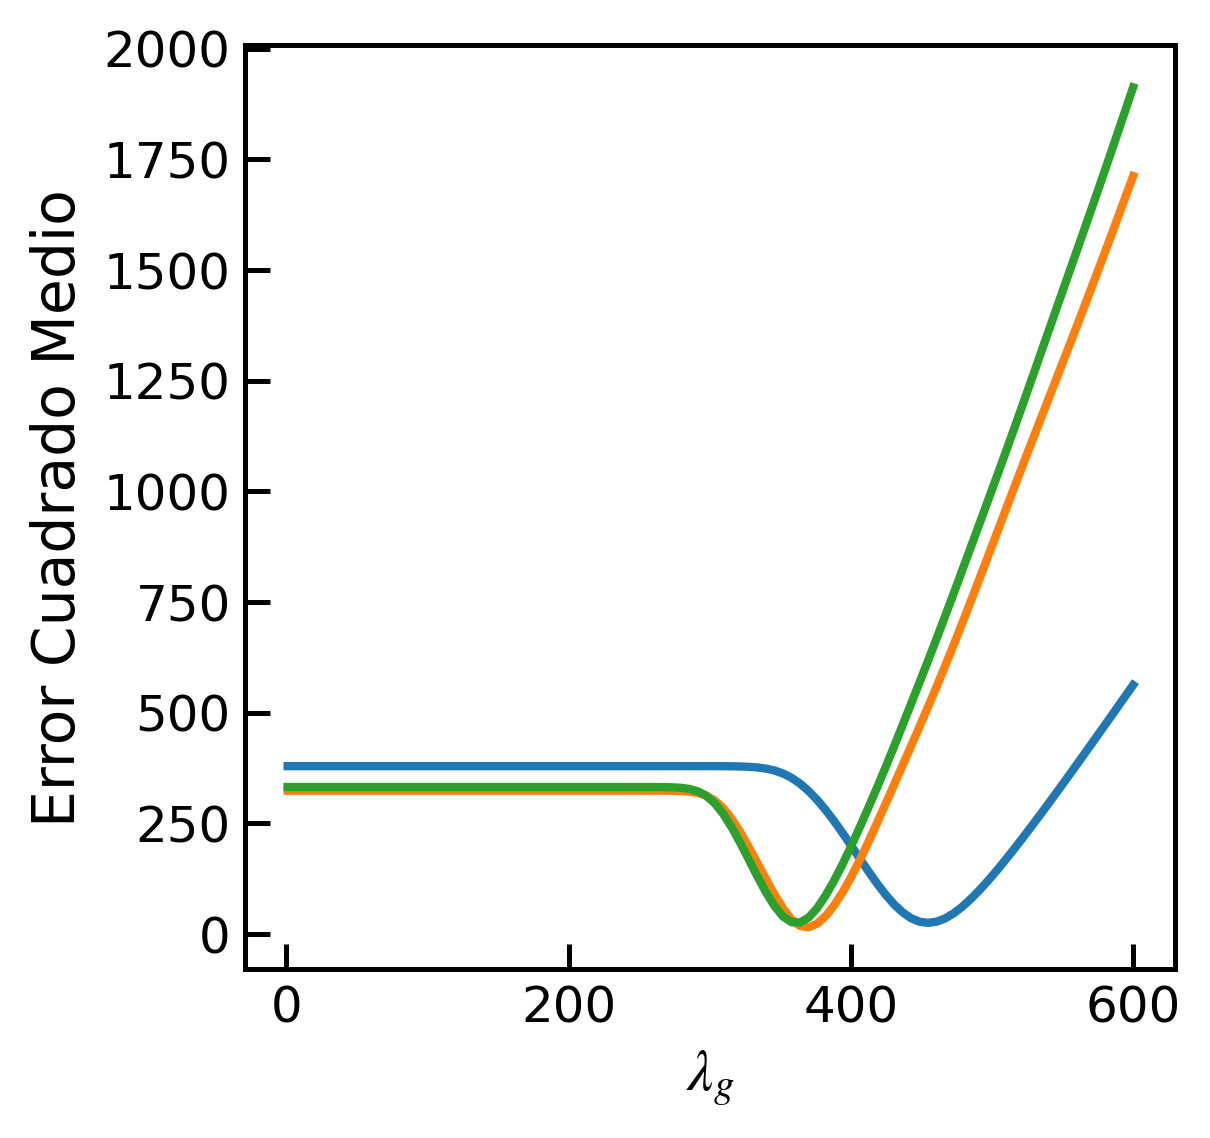

In [19]:
plt.figure(figsize = (4,4))
for i in range(1, 1501, 500): # Espesor de 1 nm a 1500 nm a un paso de 500 
    plt.plot(y, error_vec(i, y) ) # x se grafica la longitud de onda y en y-axis se grafica el MSE. 

plt.xlabel(r'$\lambda_{g}$')
plt.ylabel('Error Cuadrado Medio')
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

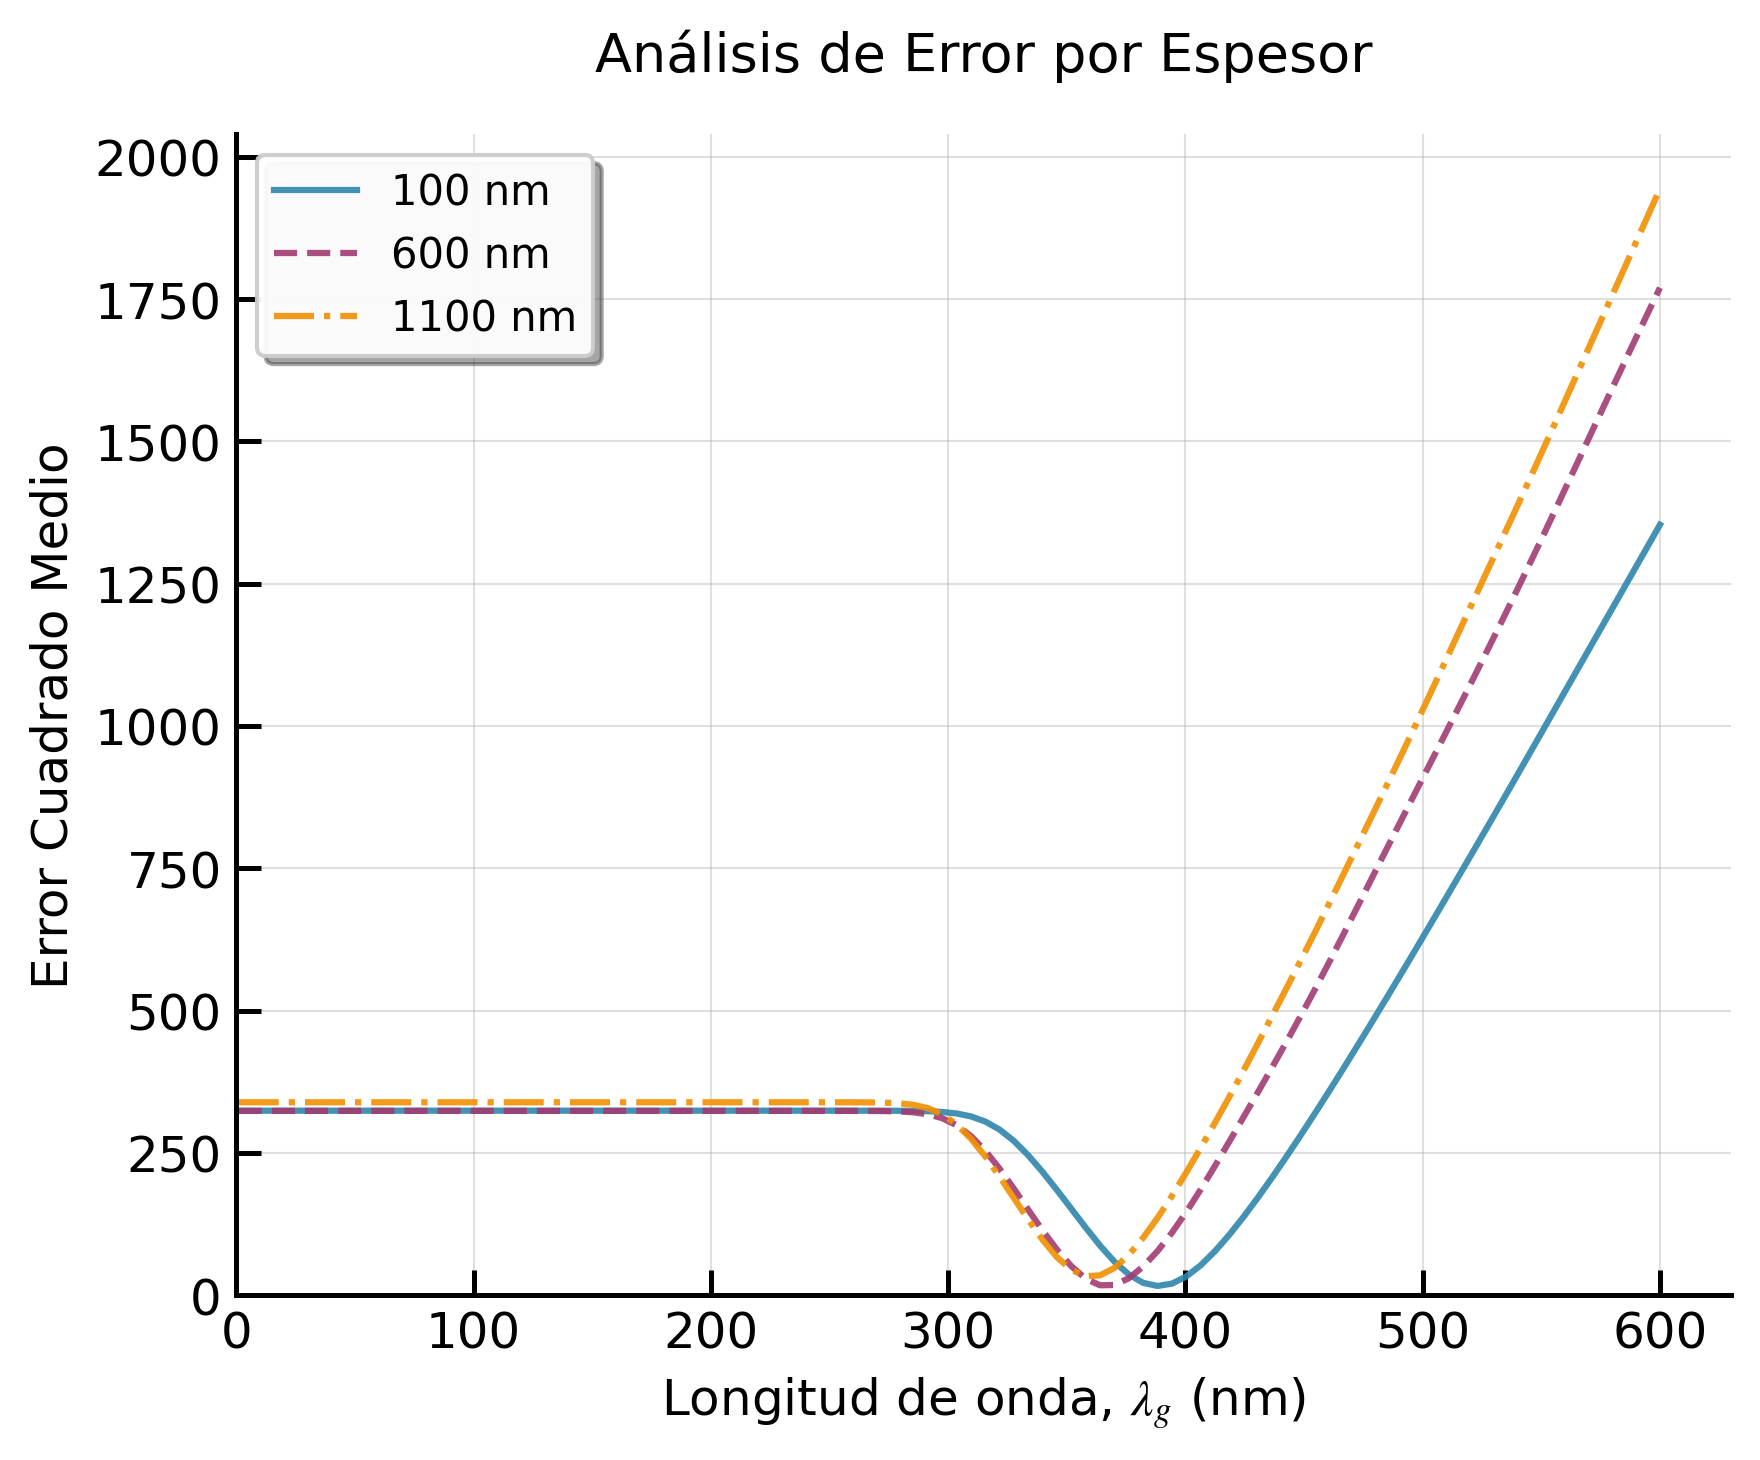

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Set up publication-quality style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 11

fig, ax = plt.subplots(figsize=(6, 5))

thicknesses = range(100, 1501, 500)
line_styles = ['-', '--', '-.', ':']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for i, thickness in enumerate(thicknesses):
    ax.plot(y, error_vec(thickness, y), 
            linewidth=1.5,
            color=colors[i],
            linestyle=line_styles[i % len(line_styles)],
            label=f'{thickness} nm',
            marker='',
            alpha=0.9)

ax.set_xlabel(r'Longitud de onda, $\lambda_{g}$ (nm)', fontsize=12)
ax.set_ylabel('Error Cuadrado Medio', fontsize=12)
ax.set_title('Análisis de Error por Espesor', fontsize=13, pad=15)

# Customize axes and grid
ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.5)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# Professional legend
ax.legend(frameon=True, fancybox=True, shadow=True, 
          framealpha=0.95, loc='best', fontsize=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()